# 04 — Quantization & Embedded Export (All 11 Activities)

Converts the best trained model to INT8 TFLite and generates C headers for Arduino deployment.

In [2]:
import numpy as np
import pickle
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.13.0


## 1. Load Model and Data

In [3]:
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')

with open(DATA_DIR / 'preprocessing_info.pkl', 'rb') as f:
    info = pickle.load(f)

with open(MODEL_DIR / 'training_info_v2.pkl', 'rb') as f:
    train_info = pickle.load(f)

ACTIVITIES = info['activities']
NUM_CLASSES = info['num_classes']
SENSOR_COLS = info['sensor_columns']
SENSOR_MEAN = info['sensor_mean']
SENSOR_STD = info['sensor_std']
WINDOW_SIZE = info['window_size']
SAMPLING_RATE = info['sampling_rate']
NUM_FEATURES = info['num_features']

best_model_name = train_info['best_model']
print(f'Best model: {best_model_name}')
print(f'Activities: {NUM_CLASSES} — {ACTIVITIES}')

# Load best model
model = tf.keras.models.load_model(MODEL_DIR / 'best_model_v2.h5')
model.summary()

# Load test data
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

# Load original (non-augmented) training data for calibration
X_train_orig = np.load(DATA_DIR / 'X_train_original.npy')

# Evaluate original model
orig_loss, orig_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nOriginal model — Test Acc: {orig_acc:.4f}, Loss: {orig_loss:.4f}')
print(f'Original model size: {Path(MODEL_DIR / "best_model_v2.h5").stat().st_size / 1024:.1f} KB')

Best model: IDCNN
Activities: 11 — ['ear_rubbing', 'forehead_rubbing', 'hair_pulling', 'hand_scratching', 'hand_tapping', 'knuckles_cracking', 'nail_biting', 'nape_rubbing', 'sitting', 'smoking', 'standing']


2026-04-29 11:40:13.444623: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-29 11:40:13.444647: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-29 11:40:13.444661: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-29 11:40:13.445051: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-29 11:40:13.445233: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "IDCNN"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 6)]             0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 128, 32)              1376      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 128, 32)              128       ['conv1d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 128, 32)              0         ['batch_normalization[0][0

2026-04-29 11:40:14.588516: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.



Original model — Test Acc: 0.5963, Loss: 1.6434
Original model size: 875.2 KB


## 2. INT8 Quantization

In [4]:
def representative_dataset_gen():
    """Yield representative samples for calibration (use original, non-augmented data)."""
    indices = np.random.choice(len(X_train_orig), size=min(200, len(X_train_orig)), replace=False)
    for i in indices:
        sample = X_train_orig[i:i+1].astype(np.float32)
        yield [sample]


# Convert to TFLite with full integer quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

# Save
tflite_path = MODEL_DIR / 'activity_model_quantized_v2.tflite'
tflite_path.write_bytes(tflite_model)

quant_size = len(tflite_model) / 1024
orig_size = Path(MODEL_DIR / 'best_model_v2.h5').stat().st_size / 1024
print(f'Quantized model size: {quant_size:.1f} KB')
print(f'Size reduction: {(1 - quant_size/orig_size)*100:.1f}%')

INFO:tensorflow:Assets written to: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpvw9aiz5t/assets


INFO:tensorflow:Assets written to: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpvw9aiz5t/assets
/opt/homebrew/Caskroom/miniforge/base/envs/tinyml/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-29 11:40:27.833445: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-04-29 11:40:27.833710: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-29 11:40:27.834384: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpvw9aiz5t
2026-04-29 11:40:27.839934: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-04-29 11:40:27.839944: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /var/folders/52/bpf46

Quantized model size: 94.8 KB
Size reduction: 89.2%


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 3. Get Quantization Parameters

In [5]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale = input_details['quantization'][0]
input_zero_point = input_details['quantization'][1]
output_scale = output_details['quantization'][0]
output_zero_point = output_details['quantization'][1]

print(f'Input  — dtype: {input_details["dtype"]}, shape: {input_details["shape"]}')
print(f'         scale: {input_scale}, zero_point: {input_zero_point}')
print(f'Output — dtype: {output_details["dtype"]}, shape: {output_details["shape"]}')
print(f'         scale: {output_scale}, zero_point: {output_zero_point}')

Input  — dtype: <class 'numpy.int8'>, shape: [  1 128   6]
         scale: 0.0858064666390419, zero_point: 31
Output — dtype: <class 'numpy.int8'>, shape: [ 1 11]
         scale: 0.00390625, zero_point: -128


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 4. Evaluate Quantized Model

In [6]:
def predict_tflite(interpreter, X):
    """Run inference on the quantized model."""
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    in_scale = input_details['quantization'][0]
    in_zp = input_details['quantization'][1]
    out_scale = output_details['quantization'][0]
    out_zp = output_details['quantization'][1]
    
    predictions = []
    for i in range(len(X)):
        # Quantize input
        sample = X[i:i+1].astype(np.float32)
        quantized_input = (sample / in_scale + in_zp).astype(np.int8)
        
        interpreter.set_tensor(input_details['index'], quantized_input)
        interpreter.invoke()
        
        output = interpreter.get_tensor(output_details['index'])[0]
        # Dequantize output
        dequantized = (output.astype(np.float32) - out_zp) * out_scale
        predictions.append(dequantized)
    
    return np.array(predictions)


quant_preds = predict_tflite(interpreter, X_test)
quant_pred_classes = quant_preds.argmax(axis=1)
quant_acc = np.mean(quant_pred_classes == y_test)

print(f'Original model accuracy:  {orig_acc:.4f}')
print(f'Quantized model accuracy: {quant_acc:.4f}')
print(f'Accuracy drop:            {(orig_acc - quant_acc)*100:.2f}%')

Original model accuracy:  0.5963
Quantized model accuracy: 0.5766
Accuracy drop:            1.96%


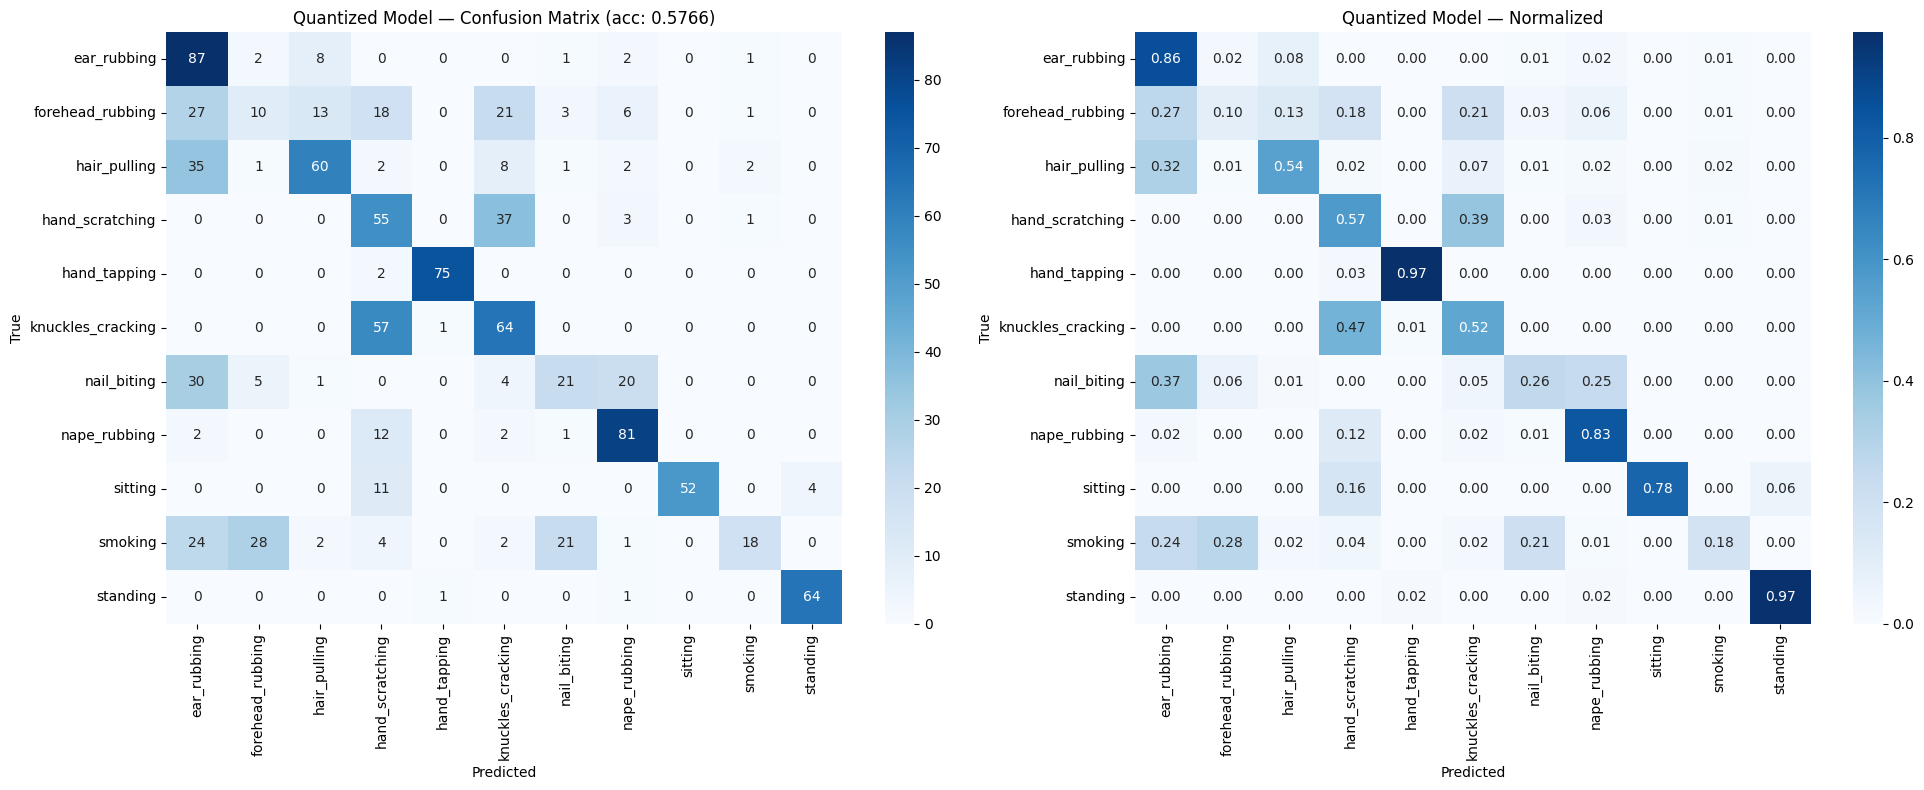

                   precision    recall  f1-score   support

      ear_rubbing     0.4244    0.8614    0.5686       101
 forehead_rubbing     0.2174    0.1010    0.1379        99
     hair_pulling     0.7143    0.5405    0.6154       111
  hand_scratching     0.3416    0.5729    0.4280        96
     hand_tapping     0.9740    0.9740    0.9740        77
knuckles_cracking     0.4638    0.5246    0.4923       122
      nail_biting     0.4375    0.2593    0.3256        81
     nape_rubbing     0.6983    0.8265    0.7570        98
          sitting     1.0000    0.7761    0.8739        67
          smoking     0.7826    0.1800    0.2927       100
         standing     0.9412    0.9697    0.9552        66

         accuracy                         0.5766      1018
        macro avg     0.6359    0.5987    0.5837      1018
     weighted avg     0.6083    0.5766    0.5569      1018



In [7]:
# Confusion matrix for quantized model
cm = confusion_matrix(y_test, quant_pred_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES, ax=ax1)
ax1.set_title(f'Quantized Model — Confusion Matrix (acc: {quant_acc:.4f})')
ax1.set_ylabel('True')
ax1.set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES, ax=ax2)
ax2.set_title('Quantized Model — Normalized')
ax2.set_ylabel('True')
ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(Path('../results') / 'quantized_confusion_matrix_v2.png', dpi=150)
plt.show()

print(classification_report(y_test, quant_pred_classes, target_names=ACTIVITIES, digits=4))

## 5. Generate C Headers for Arduino

In [8]:
# --- config.h ---
config_h = f"""#ifndef CONFIG_H
#define CONFIG_H

// Activity Recognition Configuration
// Generated from {best_model_name} model trained on all {NUM_CLASSES} activities

#define NUM_CLASSES {NUM_CLASSES}
#define NUM_FEATURES {NUM_FEATURES}
#define WINDOW_SIZE {WINDOW_SIZE}
#define SAMPLING_RATE {SAMPLING_RATE}

// Sensor normalization parameters (from training data)
const float SENSOR_MEAN[{NUM_FEATURES}] = {{{', '.join(f'{v:.6f}f' for v in SENSOR_MEAN)}}};
const float SENSOR_STD[{NUM_FEATURES}] = {{{', '.join(f'{v:.6f}f' for v in SENSOR_STD)}}};

// Quantization parameters (INT8)
const float INPUT_SCALE = {input_scale}f;
const int8_t INPUT_ZERO_POINT = {input_zero_point};
const float OUTPUT_SCALE = {output_scale}f;
const int8_t OUTPUT_ZERO_POINT = {output_zero_point};

// Activity labels
const char* ACTIVITY_LABELS[{NUM_CLASSES}] = {{
{chr(10).join(f'    "{act}",' for act in ACTIVITIES)}
}};

#endif // CONFIG_H
"""

config_path = MODEL_DIR / 'config.h'
config_path.write_text(config_h)
print(f'Saved {config_path} ({len(config_h)} bytes)')
print(config_h)

Saved ../models/config.h (975 bytes)
#ifndef CONFIG_H
#define CONFIG_H

// Activity Recognition Configuration
// Generated from IDCNN model trained on all 11 activities

#define NUM_CLASSES 11
#define NUM_FEATURES 6
#define WINDOW_SIZE 128
#define SAMPLING_RATE 50

// Sensor normalization parameters (from training data)
const float SENSOR_MEAN[6] = {0.206971f, 0.077704f, -0.466794f, -0.918844f, 1.710465f, 0.144442f};
const float SENSOR_STD[6] = {0.577543f, 0.494002f, 0.388948f, 44.305416f, 22.098326f, 19.815891f};

// Quantization parameters (INT8)
const float INPUT_SCALE = 0.0858064666390419f;
const int8_t INPUT_ZERO_POINT = 31;
const float OUTPUT_SCALE = 0.00390625f;
const int8_t OUTPUT_ZERO_POINT = -128;

// Activity labels
const char* ACTIVITY_LABELS[11] = {
    "ear_rubbing",
    "forehead_rubbing",
    "hair_pulling",
    "hand_scratching",
    "hand_tapping",
    "knuckles_cracking",
    "nail_biting",
    "nape_rubbing",
    "sitting",
    "smoking",
    "standing",
};

#endif 

In [9]:
# --- model_data.h ---
model_bytes = tflite_model

hex_lines = []
for i in range(0, len(model_bytes), 12):
    chunk = model_bytes[i:i+12]
    hex_str = ', '.join(f'0x{b:02x}' for b in chunk)
    hex_lines.append(f'  {hex_str},')

model_data_h = f"""#ifndef MODEL_DATA_H
#define MODEL_DATA_H

// TFLite model data (INT8 quantized)
// Model: {best_model_name}
// Size: {len(model_bytes):,} bytes
// Activities: {NUM_CLASSES}

alignas(8) const unsigned char activity_model_data[] = {{
{chr(10).join(hex_lines)}
}};

const unsigned int activity_model_data_len = {len(model_bytes)};

#endif // MODEL_DATA_H
"""

model_data_path = MODEL_DIR / 'model_data.h'
model_data_path.write_text(model_data_h)
print(f'Saved {model_data_path} ({len(model_data_h):,} bytes)')
print(f'Model binary: {len(model_bytes):,} bytes')

Saved ../models/model_data.h (598,935 bytes)
Model binary: 97,080 bytes


## 6. Summary

In [10]:
# Save quantization report
quant_report = {
    'best_model': best_model_name,
    'original_accuracy': float(orig_acc),
    'quantized_accuracy': float(quant_acc),
    'accuracy_drop': float(orig_acc - quant_acc),
    'original_size_kb': orig_size,
    'quantized_size_kb': quant_size,
    'size_reduction_pct': (1 - quant_size/orig_size) * 100,
    'model_bytes': len(model_bytes),
    'input_scale': float(input_scale),
    'input_zero_point': int(input_zero_point),
    'output_scale': float(output_scale),
    'output_zero_point': int(output_zero_point),
    'num_classes': NUM_CLASSES,
    'activities': ACTIVITIES,
}

with open(MODEL_DIR / 'quantization_report_v2.pkl', 'wb') as f:
    pickle.dump(quant_report, f)

print('=' * 50)
print('QUANTIZATION SUMMARY')
print('=' * 50)
print(f'Model:              {best_model_name}')
print(f'Activities:         {NUM_CLASSES}')
print(f'Original accuracy:  {orig_acc:.4f}')
print(f'Quantized accuracy: {quant_acc:.4f}')
print(f'Accuracy drop:      {(orig_acc - quant_acc)*100:.2f}%')
print(f'Original size:      {orig_size:.1f} KB')
print(f'Quantized size:     {quant_size:.1f} KB')
print(f'Size reduction:     {(1 - quant_size/orig_size)*100:.1f}%')
print(f'Model binary:       {len(model_bytes):,} bytes')
print(f'\nGenerated files:')
print(f'  models/config.h')
print(f'  models/model_data.h')
print(f'  models/activity_model_quantized_v2.tflite')
print(f'\nCopy config.h and model_data.h to the embedded project\'s IMU_Classifier/ folder.')

QUANTIZATION SUMMARY
Model:              IDCNN
Activities:         11
Original accuracy:  0.5963
Quantized accuracy: 0.5766
Accuracy drop:      1.96%
Original size:      875.2 KB
Quantized size:     94.8 KB
Size reduction:     89.2%
Model binary:       97,080 bytes

Generated files:
  models/config.h
  models/model_data.h
  models/activity_model_quantized_v2.tflite

Copy config.h and model_data.h to the embedded project's IMU_Classifier/ folder.
